---
title: "The singular value decomposition"
categories: []
---


The singular value decomposition is the central theorem of the course: the
spectral theorem, generalized from symmetric square matrices to arbitrary
ones. Every matrix $\mathbf{A} \in \mathbb{R}^{m \times n}$ factors as

$$
\mathbf{A} = \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^{\mathsf T},
\qquad
\mathbf{U}^{\mathsf T}\mathbf{U} = \mathbf{I}_m,\quad
\mathbf{V}^{\mathsf T}\mathbf{V} = \mathbf{I}_n,
$$

where $\boldsymbol{\Sigma} \in \mathbb{R}^{m \times n}$ is diagonal with
nonnegative entries $\sigma_1 \ge \sigma_2 \ge \dots \ge 0$ down its main
diagonal, and both $\mathbf{U}$ and $\mathbf{V}$ are orthogonal. The numbers
$\sigma_i$ are the **singular values**, the columns of $\mathbf{U}$ the
**left singular vectors**, and the columns of $\mathbf{V}$ the **right
singular vectors**.

Unlike the eigenvalue theory of a general square matrix, which can fail in
spectacular ways (chapter 9), the SVD *always* exists, is *always* real for a
real matrix, and is *always* built from orthonormal bases. This is why it is
the workhorse: it gives every matrix an orthogonal change of basis in both its
domain and its codomain, at once.


## Three forms of the SVD

Let $\mathbf{A} \in \mathbb{R}^{m \times n}$ and $r = \operatorname{rank}\mathbf{A}$.
The theorem has three standard incarnations, distinguished by how much padding
each factor carries.

- **Full SVD.** $\mathbf{A} = \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^{\mathsf T}$
  with $\mathbf{U} \in \mathbb{R}^{m \times m}$ orthogonal,
  $\boldsymbol{\Sigma} \in \mathbb{R}^{m \times n}$ diagonal (rectangular
  diagonal, zero beyond position $r$), and
  $\mathbf{V} \in \mathbb{R}^{n \times n}$ orthogonal.
- **Compact (reduced) SVD.** $\mathbf{A} = \mathbf{U}_r\boldsymbol{\Sigma}_r\mathbf{V}_r^{\mathsf T}$,
  keeping only the $r$ nonzero singular values:
  $\mathbf{U}_r \in \mathbb{R}^{m \times r}$ with orthonormal columns,
  $\boldsymbol{\Sigma}_r = \operatorname{diag}(\sigma_1,\dots,\sigma_r) \in \mathbb{R}^{r \times r}$,
  $\mathbf{V}_r \in \mathbb{R}^{n \times r}$.
- **Rank-one sum.** The same information as a sum of outer products,

$$
\mathbf{A} = \sum_{i=1}^r \sigma_i \mathbf{u}_i \mathbf{v}_i^{\mathsf T}.
$$

The rank-one form is the most useful for thinking. Each term is a rank-one
matrix (a column times a row), so $\mathbf{A}$ is written as $r$ simple pieces
weighted by the singular values — the full-blown version of view 4 of matrix
multiplication from chapter 1.


## Geometry: rotate, stretch, rotate

The SVD says a matrix does three things, in order. Reading
$\mathbf{A} = \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^{\mathsf T}$ from right
to left:

1. $\mathbf{V}^{\mathsf T}$ rotates the input so the standard axes line up
   with the right singular vectors $\mathbf{v}_1, \dots, \mathbf{v}_n$;
2. $\boldsymbol{\Sigma}$ stretches axis $i$ by the factor $\sigma_i$;
3. $\mathbf{U}$ rotates the result so the stretched axes line up with the
   left singular vectors $\mathbf{u}_1, \dots, \mathbf{u}_m$.

Consequently a matrix sends the unit sphere to a **hyperellipse** whose
principal axes are $\sigma_1\mathbf{u}_1, \dots, \sigma_r\mathbf{u}_r$; the
directions with $\sigma_i = 0$ collapse to the origin. The
largest stretch is $\sigma_1$, the smallest nonzero stretch $\sigma_r$; a
singular matrix is exactly one that flattens at least one axis.


In [1]:
from watchtower.core import set_format
set_format("svg")


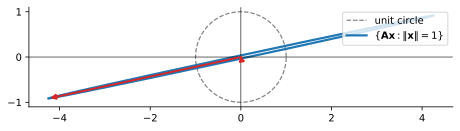

singular values: [4.349 0.035]


In [2]:
#| label: fig-svd-geometry
#| cap: "**Rotate, stretch, rotate.** A $2\\times2$ matrix maps the unit circle to an ellipse. The red arrows are $\\mathbf{A}\\mathbf{v}_i = \\sigma_i\\mathbf{u}_i$: the images of the right singular vectors, equal to the ellipse's axes. Their lengths are the singular values, the per-axis stretch factors."
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(3)
A = rng.normal(size=(2, 2)) * 1.3
U, S, Vt = np.linalg.svd(A)

t = np.linspace(0, 2 * np.pi, 500)
circle = np.c_[np.cos(t), np.sin(t)]
image = circle @ A.T                          # row-wise A x

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.plot(circle[:, 0], circle[:, 1], ls="--", lw=1.2, color="gray",
        label="unit circle")
ax.plot(image[:, 0], image[:, 1], lw=2.2, color="#1f77b4",
        label=r"$\{\mathbf{A}\mathbf{x} : \|\mathbf{x}\|=1\}$")
for i in range(2):
    Av = A @ Vt[i]                            # = sigma_i u_i
    ax.annotate("", xy=Av, xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color="#d62728", lw=2))
ax.set_aspect("equal")
ax.axhline(0, color="k", lw=0.6); ax.axvline(0, color="k", lw=0.6)
for sp in ("top", "right"): ax.spines[sp].set_visible(False)
ax.legend(fontsize=10, loc="upper right")
plt.tight_layout()
plt.show()

print("singular values:", np.round(S, 3))


The figure makes $\sigma_1$ visible as the largest distance from the origin
attained by any unit vector. That observation anticipates the variational
characterization below and the operator norm identity that resolves the
chapter-1 definition.


## The theorem, proved

> **Theorem (singular value decomposition).** Every
> $\mathbf{A} \in \mathbb{R}^{m \times n}$ admits a factorization
> $\mathbf{A} = \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^{\mathsf T}$ with
> $\mathbf{U}, \mathbf{V}$ orthogonal and $\boldsymbol{\Sigma}$ diagonal with
> nonnegative entries. Moreover $\operatorname{rank}\mathbf{A}$ equals the
> number of nonzero $\sigma_i$.

*Proof.* The matrix $\mathbf{A}^{\mathsf T}\mathbf{A} \in \mathbb{R}^{n \times n}$
is symmetric and positive semidefinite, since
$\mathbf{x}^{\mathsf T}\mathbf{A}^{\mathsf T}\mathbf{A}\mathbf{x} = \lVert \mathbf{A}\mathbf{x}\rVert^2 \ge 0$.
By the spectral theorem (chapter 2) it diagonalizes over an orthonormal basis
with nonnegative eigenvalues:

$$
\mathbf{A}^{\mathsf T}\mathbf{A}
= \mathbf{V}\boldsymbol{\Sigma}^2\mathbf{V}^{\mathsf T},
\qquad
\boldsymbol{\Sigma}^2 = \operatorname{diag}(\sigma_1^2, \dots, \sigma_n^2),
\qquad
\sigma_1 \ge \cdots \ge \sigma_n \ge 0 .
$$

Let $r$ be the number of *positive* $\sigma_i$. For $i \le r$ define
$\mathbf{u}_i = \mathbf{A}\mathbf{v}_i / \sigma_i \in \mathbb{R}^m$. These are
orthonormal:

$$
\mathbf{u}_i^{\mathsf T}\mathbf{u}_j
= \frac{\mathbf{v}_i^{\mathsf T}\mathbf{A}^{\mathsf T}\mathbf{A}\mathbf{v}_j}{\sigma_i\sigma_j}
= \frac{\sigma_j^2\,\mathbf{v}_i^{\mathsf T}\mathbf{v}_j}{\sigma_i\sigma_j}
= \delta_{ij} .
$$

Extend $\mathbf{u}_1,\dots,\mathbf{u}_r$ to an orthonormal basis
$\mathbf{u}_1,\dots,\mathbf{u}_m$ of $\mathbb{R}^m$ (any orthonormal
completion of the missing directions). For $i > r$ the vector
$\mathbf{A}\mathbf{v}_i$ vanishes, because
$\lVert \mathbf{A}\mathbf{v}_i\rVert^2 = \mathbf{v}_i^{\mathsf T}\mathbf{A}^{\mathsf T}\mathbf{A}\mathbf{v}_i = \sigma_i^2 = 0$.
Hence $\mathbf{A}\mathbf{v}_i = \sigma_i\mathbf{u}_i$ for $i \le r$ and
$\mathbf{A}\mathbf{v}_i = \mathbf{0}$ for $i > r$, so

$$
\mathbf{A} = \sum_{i=1}^r \sigma_i \mathbf{u}_i \mathbf{v}_i^{\mathsf T}
= \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^{\mathsf T},
$$

with $\mathbf{U} = [\mathbf{u}_1\ \cdots\ \mathbf{u}_m]$,
$\mathbf{V} = [\mathbf{v}_1\ \cdots\ \mathbf{v}_n]$, and
$\boldsymbol{\Sigma}$ carrying the $\sigma_i$. Finally
$\operatorname{rank}\mathbf{A} = r$: the vectors $\mathbf{u}_1,\dots,\mathbf{u}_r$
form an orthonormal basis of the column space of $\mathbf{A}$, since
$\mathbf{A}\mathbf{v}_i = \sigma_i\mathbf{u}_i$ for $i \le r$ and vanishes
thereafter, so the $\sigma_i\mathbf{u}_i$ span the same column space. $\square$

The proof is constructive except for the orthonormal completion of the left
singular vectors — a Gram–Schmidt step, which chapter 7 makes mechanical. The
only real input is the spectral theorem on $\mathbf{A}^{\mathsf T}\mathbf{A}$,
which is why chapter 2 came first.


## The variational characterization

The largest singular value has a meaning independent of the factorization: it
is the operator norm, the largest stretch a matrix can inflict on a unit
vector.

$$
\sigma_1 = \lVert \mathbf{A}\rVert_2
= \max_{\lVert \mathbf{x}\rVert = 1} \lVert \mathbf{A}\mathbf{x}\rVert .
$$

Expanding in the right singular vectors,
$\lVert \mathbf{A}\mathbf{x}\rVert^2 = \mathbf{x}^{\mathsf T}\mathbf{A}^{\mathsf T}\mathbf{A}\mathbf{x} = \sum_i \sigma_i^2 (\mathbf{v}_i^{\mathsf T}\mathbf{x})^2 \le \sigma_1^2 \sum_i (\mathbf{v}_i^{\mathsf T}\mathbf{x})^2 = \sigma_1^2 \lVert \mathbf{x}\rVert^2$,
with equality at $\mathbf{x} = \mathbf{v}_1$. So the supremum is $\sigma_1$,
attained at $\mathbf{v}_1$. This closes the loop with chapter 1, where the
operator norm was introduced abstractly: it is now identified with the top
singular value. Every intermediate $\sigma_k$ admits a similar, constrained
description (the Courant–Fischer principle for rectangular matrices), but
$\sigma_1$ and $\sigma_r$ are the ones the course uses.


## The polar decomposition

For a *square* $\mathbf{A} \in \mathbb{R}^{n \times n}$ the SVD reorganizes
into a single isometry times a single symmetric positive semidefinite
stretch.

> **Polar decomposition.** Every square $\mathbf{A}$ factors as
> $\mathbf{A} = \mathbf{Q}\mathbf{P}$ with $\mathbf{Q}$ orthogonal and
> $\mathbf{P}$ symmetric positive semidefinite. The factor
> $\mathbf{P} = \sqrt{\mathbf{A}^{\mathsf T}\mathbf{A}}$ is unique; $\mathbf{Q}$
> is unique only when $\mathbf{A}$ is invertible.

*Existence.* Write the SVD $\mathbf{A} = \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^{\mathsf T}$
and group it as

$$
\mathbf{A} = (\mathbf{U}\mathbf{V}^{\mathsf T})(\mathbf{V}\boldsymbol{\Sigma}\mathbf{V}^{\mathsf T})
= \mathbf{Q}\mathbf{P},
$$

where $\mathbf{Q} = \mathbf{U}\mathbf{V}^{\mathsf T}$ is orthogonal (a product
of orthogonal matrices) and $\mathbf{P} = \mathbf{V}\boldsymbol{\Sigma}\mathbf{V}^{\mathsf T}$
is the positive semidefinite square root of
$\mathbf{A}^{\mathsf T}\mathbf{A} = \mathbf{V}\boldsymbol{\Sigma}^2\mathbf{V}^{\mathsf T}$
constructed in chapter 2. *Uniqueness of $\mathbf{P}$*: any $\mathbf{P}$ with
$\mathbf{P} \succeq 0$ and $\mathbf{P}^2 = \mathbf{A}^{\mathsf T}\mathbf{A}$
must be the principal square root, which is unique. *Non-uniqueness of
$\mathbf{Q}$ when singular*: along a collapsed direction (a zero singular
value) one may reflect freely without changing $\mathbf{A}$. $\square$

The name is exact: a complex number factors in polar coordinates as
$z = r e^{i\theta}$ with $r = \sqrt{\bar z z} \ge 0$ and $|e^{i\theta}| = 1$;
the matrix analog replaces the nonnegative modulus $r$ by $\sqrt{\mathbf{A}^{\mathsf T}\mathbf{A}}$
and the unit complex number $e^{i\theta}$ by the isometry $\mathbf{Q}$. The
decomposition separates "how much does $\mathbf{A}$ stretch" ($\mathbf{P}$)
from "how much does it rotate or reflect" ($\mathbf{Q}$).


## Singular values and the Gram matrices

The two Gram matrices of $\mathbf{A}$ share its nonzero singular values.
Because $\mathbf{A}^{\mathsf T}\mathbf{A}\mathbf{v}_i = \sigma_i^2\mathbf{v}_i$
and, symmetrically,

$$
\mathbf{A}\mathbf{A}^{\mathsf T}\mathbf{u}_i
= \mathbf{A}\frac{\mathbf{A}^{\mathsf T}\mathbf{A}\mathbf{v}_i}{\sigma_i}
= \frac{\sigma_i^2 \mathbf{A}\mathbf{v}_i}{\sigma_i}
= \sigma_i^2 \mathbf{u}_i,
$$

the right singular vectors diagonalize $\mathbf{A}^{\mathsf T}\mathbf{A}$ and
the left ones diagonalize $\mathbf{A}\mathbf{A}^{\mathsf T}$, both with
eigenvalues $\sigma_i^2$ (and zeros beyond $r$). The nonzero singular values of
$\mathbf{A}$ and $\mathbf{A}^{\mathsf T}$ coincide. Unlike eigenvalues,
singular values treat a matrix and its transpose symmetrically: both have the
same 'size' in every singular direction.


## Constructing the SVD from scratch

The proof is executable. Follow it literally: diagonalize
$\mathbf{A}^{\mathsf T}\mathbf{A}$, take square roots for $\boldsymbol{\Sigma}$,
and form $\mathbf{U}$ as the normalized images $\mathbf{A}\mathbf{v}_i/\sigma_i$.


In [3]:
rng = np.random.default_rng(0)
A = rng.normal(size=(5, 4))
m, n = A.shape

lam, V = np.linalg.eigh(A.T @ A)             # spectral theorem on A^T A
order = np.argsort(-lam)                      # descending
lam, V = lam[order], V[:, order]
sigma = np.sqrt(np.maximum(lam, 0.0))        # singular values
r = int(np.sum(sigma > 1e-10))

Ur = np.zeros((m, r))
for i in range(r):
    Ur[:, i] = A @ V[:, i] / sigma[i]        # u_i = A v_i / sigma_i

Sr, Vr = np.diag(sigma[:r]), V[:, :r]
print("A == U_r Sigma_r V_r^T :", np.allclose(A, Ur @ Sr @ Vr.T))
print("U_r orthonormal        :", np.allclose(Ur.T @ Ur, np.eye(r)))
print("V  orthonormal         :", np.allclose(V.T @ V, np.eye(n)))
print("sigma_1 == ||A||_2     :", np.allclose(sigma[0], np.linalg.norm(A, 2)))


A == U_r Sigma_r V_r^T : True
U_r orthonormal        : True
V  orthonormal         : True
sigma_1 == ||A||_2     : True


The compact SVD is recovered exactly from the spectral decomposition of
$\mathbf{A}^{\mathsf T}\mathbf{A}$, and the top singular value matches the
operator norm computed independently by `np.linalg.norm`. The only part of the
proof not reproduced here is the orthonormal completion of $\mathbf{U}$ to a
full $m \times m$ matrix, which the compact form (dropping the zero singular
values and their corresponding vectors) does not need.


## The condition number

The singular values quantify a matrix's fragility. Solving
$\mathbf{A}\mathbf{x} = \mathbf{b}$ for invertible square $\mathbf{A}$ is
sensitive to the ratio of the extreme singular values.

> **Condition number.** For invertible $\mathbf{A}$, define
> $\kappa(\mathbf{A}) = \lVert \mathbf{A}\rVert_2\,\lVert \mathbf{A}^{-1}\rVert_2 = \sigma_1 / \sigma_n$.
> Then a perturbation $\delta\mathbf{b}$ of the right-hand side perturbs the
> solution by at most
>
> $$
> \frac{\lVert \delta\mathbf{x}\rVert}{\lVert \mathbf{x}\rVert}
> \le \kappa(\mathbf{A})\,\frac{\lVert \delta\mathbf{b}\rVert}{\lVert \mathbf{b}\rVert} .
> $$

*Proof.* $\mathbf{A}\delta\mathbf{x} = \delta\mathbf{b}$ gives
$\lVert \delta\mathbf{x}\rVert \le \lVert \mathbf{A}^{-1}\rVert\lVert \delta\mathbf{b}\rVert$,
while $\lVert \mathbf{b}\rVert = \lVert \mathbf{A}\mathbf{x}\rVert \le \lVert \mathbf{A}\rVert\lVert \mathbf{x}\rVert$,
so $\lVert \mathbf{x}\rVert^{-1} \le \lVert \mathbf{A}\rVert/\lVert \mathbf{b}\rVert$.
Multiplying,

$$
\lVert \delta\mathbf{x}\rVert
\le \lVert \mathbf{A}^{-1}\rVert\lVert \delta\mathbf{b}\rVert
= \lVert \mathbf{A}\rVert\lVert \mathbf{A}^{-1}\rVert
\cdot \frac{\lVert \delta\mathbf{b}\rVert}{\lVert \mathbf{A}\rVert}
\le \kappa(\mathbf{A})\,\frac{\lVert \delta\mathbf{b}\rVert\,\lVert \mathbf{x}\rVert}{\lVert \mathbf{b}\rVert},
$$

which rearranges to the claim. The second equality uses
$\lVert \mathbf{A}\rVert = \sigma_1$ and
$\lVert \mathbf{A}^{-1}\rVert = 1/\sigma_n$, since $\mathbf{A}^{-1}$ has
singular values $1/\sigma_i$. $\square$

The bound is *attained*. Since $\mathbf{A}^{-1}\mathbf{u}_i = \mathbf{v}_i/\sigma_i$, the direction $\mathbf{A}^{-1}$ stretches most is $\mathbf{u}_n$: it is mapped to $\mathbf{v}_n/\sigma_n$, the largest factor $1/\sigma_n$. When $\mathbf{x}$ aligns with $\mathbf{v}_1$ (so $\lVert\mathbf{b}\rVert = \sigma_1\lVert\mathbf{x}\rVert$) and $\delta\mathbf{b}$ aligns with $\mathbf{u}_n$, the relative error is exactly $\kappa(\mathbf{A})$ times the relative input perturbation. A large condition number is the numerical meaning of "nearly singular" — the matrix inverts some directions so weakly that tiny errors in $\mathbf{b}$ are amplified enormously in $\mathbf{x}$.


In [4]:
rng = np.random.default_rng(1)
n = 100
Q, _ = np.linalg.qr(rng.normal(size=(n, n)))
W, _ = np.linalg.qr(rng.normal(size=(n, n)))
sigma = np.geomspace(1, 1e3, n)              # sigma_1..sigma_n = 1..1000
A = Q @ np.diag(sigma) @ W.T

x = rng.normal(size=n)
b = A @ x
db = rng.normal(size=n)
db = db / np.linalg.norm(db) * np.linalg.norm(b) * 1e-4
x_tilde = np.linalg.solve(A, b + db)

rel_x = np.linalg.norm(x_tilde - x) / np.linalg.norm(x)
rel_b = np.linalg.norm(db) / np.linalg.norm(b)
print("kappa(A)              =", np.linalg.cond(A))
print("rel_x / rel_b (<= kappa):", rel_x / rel_b)


kappa(A)              = 1000.0000000000107
rel_x / rel_b (<= kappa): 57.838345144508374


The amplification factor $\lVert \delta\mathbf{x}\rVert/\lVert \mathbf{x}\rVert$
divided by $\lVert \delta\mathbf{b}\rVert/\lVert \mathbf{b}\rVert$ lands below
$\kappa(\mathbf{A}) = 1000$, as the theorem requires; a *generic* random
perturbation lands well below the worst case, since the worst case requires
$\delta\mathbf{b}$ to align precisely with $\mathbf{u}_1$. The condition
number is a worst-case guarantee, not a typical-case prediction — the same gap
between generic and extremal behavior seen with the norm inequalities of
chapter 1.


## Low-rank structure and the layer perspective

The rank-one form $\mathbf{A} = \sum_{i=1}^r \sigma_i \mathbf{u}_i \mathbf{v}_i^{\mathsf T}$
reads as a *layered* decomposition: the matrix is a sum of $r$ layers, the
$i$-th contributing $\sigma_i\mathbf{u}_i\mathbf{v}_i^{\mathsf T}$ with weight
$\sigma_i$. Truncating after $k$ layers gives

$$
\mathbf{A}_k = \sum_{i=1}^k \sigma_i \mathbf{u}_i \mathbf{v}_i^{\mathsf T},
\qquad
\operatorname{rank}\mathbf{A}_k = k .
$$

A matrix whose **scree plot** drops off quickly — a few dominant singular
values — has its essential content in a low-dimensional subspace; everything
below the knee of the plot is structure that can be discarded at small cost.
Matrices with genuine low-rank *signal* decay fast; pure noise
decays slowly and uniformly, its scree plot nearly flat.


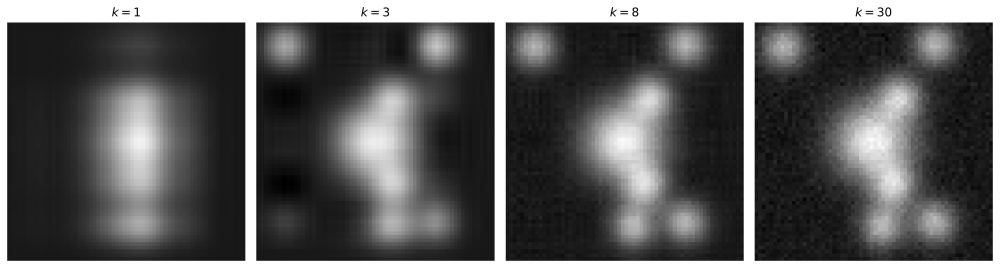

total singular values: 64
energy in first 8 layers: 0.9936763507322495


In [5]:
#| label: fig-svd-lowrank
#| cap: "**Low-rank reconstruction.** A structured image (smooth blobs plus faint noise) reconstructed from its first $k$ layers. By $k = 8$ the signal is essentially recovered; the remaining layers capture only the noise."
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
n = 64
xx, yy = np.meshgrid(np.linspace(-3, 3, n), np.linspace(-3, 3, n))
img = np.exp(-(xx**2 + yy**2))                # central blob
for _ in range(6):
    cx, cy = rng.uniform(-2.5, 2.5, 2)
    img += 0.7 * np.exp(-((xx - cx)**2 + (yy - cy)**2) / 0.3)
img += 0.03 * rng.normal(size=(n, n))         # faint noise

U, S, Vt = np.linalg.svd(img)
ks = [1, 3, 8, 30]
fig, axes = plt.subplots(1, len(ks), figsize=(14, 3.8))
for ax, k in zip(axes, ks):
    Ak = (U[:, :k] * S[:k]) @ Vt[:k, :]
    ax.imshow(Ak, cmap="gray", vmin=img.min(), vmax=img.max())
    ax.set_title(f"$k = {k}$", fontsize=12)
    ax.axis("off")
plt.tight_layout()
plt.show()

print("total singular values:", len(S))
print("energy in first 8 layers:", (S[:8]**2).sum() / (S**2).sum())


The first layer captures the dominant brightness, the next few the individual
blobs, and by $k = 8$ essentially all the *signal* is present; the noise
requires a long tail of small singular values. The fraction of squared
Frobenius norm (energy) retained by the first $k$ layers is
$\sum_{i\le k}\sigma_i^2 / \sum_i \sigma_i^2$, and it rises fast when the
signal is low-rank. This is the quantitative meaning of "the layers are the
information": singular values order the layers by how much of $\mathbf{A}$
they explain.


## Eckart–Young: the truncated SVD is optimal

Given the scree plot, truncating at $k$ is the natural approximation — but is
it the *best* rank-$k$ approximation? The answer is the Eckart–Young theorem:
nothing beats the truncated SVD.

> **Theorem (Eckart–Young).** For any matrix $\mathbf{B}$ of rank at most
> $k$,
>
> $$
> \lVert \mathbf{A} - \mathbf{B}\rVert_2 \ge \lVert \mathbf{A} - \mathbf{A}_k\rVert_2 = \sigma_{k+1},
> $$
>
> and the same holds with the Frobenius norm, where
> $\lVert \mathbf{A} - \mathbf{A}_k\rVert_F = \big(\sum_{i > k} \sigma_i^2\big)^{1/2}$.

*Proof (operator norm).* Since $\operatorname{rank}\mathbf{B} \le k$, the
rank–nullity theorem (chapter 4) gives
$\dim \operatorname{null}\mathbf{B} \ge n - k$. The subspace
$W = \operatorname{span}\{\mathbf{v}_1, \dots, \mathbf{v}_{k+1}\}$ has
dimension $k + 1$, and

$$
\dim \operatorname{null}\mathbf{B} + \dim W \ge (n-k) + (k+1) = n + 1 > n,
$$

so the two subspaces intersect nontrivially. Choose a unit vector
$\mathbf{w} \in \operatorname{null}\mathbf{B} \cap W$, written
$\mathbf{w} = \sum_{i=1}^{k+1} c_i \mathbf{v}_i$ with $\sum_i c_i^2 = 1$. Then

$$
\lVert \mathbf{A} - \mathbf{B}\rVert_2^2
\ge \lVert (\mathbf{A} - \mathbf{B})\mathbf{w}\rVert^2
= \lVert \mathbf{A}\mathbf{w}\rVert^2
= \sum_{i=1}^{k+1} c_i^2 \sigma_i^2
\ge \sigma_{k+1}^2 \sum_{i=1}^{k+1} c_i^2
= \sigma_{k+1}^2,
$$

using $\mathbf{B}\mathbf{w} = \mathbf{0}$ in the second step and
$\sigma_i \ge \sigma_{k+1}$ in the last. Since
$\mathbf{A} - \mathbf{A}_k = \sum_{i > k}\sigma_i\mathbf{u}_i\mathbf{v}_i^{\mathsf T}$
has operator norm exactly $\sigma_{k+1}$, the bound is tight and
$\mathbf{A}_k$ attains it. $\square$

The argument has a concrete geometric reading. A rank-$k$ matrix $\mathbf{B}$
kills an $(n-k)$-dimensional subspace; among the $k+1$ most important
directions $\mathbf{v}_1,\dots,\mathbf{v}_{k+1}$, some nonzero combination
must fall in that kernel, and along it $\mathbf{B}$ does nothing where
$\mathbf{A}$ stretches by at least $\sigma_{k+1}$. That unavoidable
discrepancy is the lower bound, and $\mathbf{A}_k$ hits it exactly.

*Frobenius norm.* The operator-norm argument does not carry over: the matching
lower bound $\lVert\mathbf{A} - \mathbf{B}\rVert_F \ge \big(\sum_{i>k}\sigma_i^2\big)^{1/2}$
is [Mirsky's theorem](https://en.wikipedia.org/wiki/Low-rank_approximation#Basic_low-rank_approximation_problems),
a consequence of singular-value interlacing, not of the intersection argument above.


In [6]:
rng = np.random.default_rng(2)
A = rng.normal(size=(8, 6))
U, S, Vt = np.linalg.svd(A)

for k in range(5):
    Ak = (U[:, :k] * S[:k]) @ Vt[:k, :]
    err_op = np.linalg.norm(A - Ak, 2)
    err_fr = np.linalg.norm(A - Ak, "fro")
    print(f"k={k}: ||A-Ak||_2 = {err_op:.4f}   sigma_{{k+1}} = {S[k]:.4f}   "
          f"||A-Ak||_F = {err_fr:.4f}")


k=0: ||A-Ak||_2 = 4.3141   sigma_{k+1} = 4.3141   ||A-Ak||_F = 6.5786
k=1: ||A-Ak||_2 = 3.4712   sigma_{k+1} = 3.4712   ||A-Ak||_F = 4.9666
k=2: ||A-Ak||_2 = 2.3460   sigma_{k+1} = 2.3460   ||A-Ak||_F = 3.5521
k=3: ||A-Ak||_2 = 1.9331   sigma_{k+1} = 1.9331   ||A-Ak||_F = 2.6671
k=4: ||A-Ak||_2 = 1.5477   sigma_{k+1} = 1.5477   ||A-Ak||_F = 1.8376


The Eckart–Young theorem converts the scree plot from a descriptive device
into a guarantee: the rank-$k$ truncation of the SVD is not merely good, it is
the best possible rank-$k$ approximation in both the operator and Frobenius
norms. The two norms report the error differently: the operator norm sees the
single worst direction ($\sigma_{k+1}$), the Frobenius norm the total tail
energy $\big(\sum_{i>k}\sigma_i^2\big)^{1/2}$.


## Summary

The SVD now packages a great deal into one factorization: the rank (number of
nonzero singular values), the operator norm ($\sigma_1$), the condition number
($\sigma_1/\sigma_n$ when $\mathbf{A}$ is invertible), the best low-rank approximation (truncated SVD), the
polar decomposition, and — as the proof showed — the column space of
$\mathbf{A}$, spanned by $\mathbf{u}_1,\dots,\mathbf{u}_r$. The next chapter
turns that last observation into a systematic account of the four fundamental
subspaces: where $\mathbf{A}$ maps, where it collapses, and how the two are
related.


## Problems

The problems below exercise the chapter's definitions and theorems: the Gram
matrices, the polar decomposition, the constructive proof, Eckart–Young, and
the condition number as a worst-case guarantee.


### Problem 1 — Singular values of the Gram matrices

Let $\mathbf{A} \in \mathbb{R}^{m \times n}$ have full SVD
$\mathbf{A} = \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^{\mathsf T}$.

(a) Show that the nonzero eigenvalues of $\mathbf{A}^{\mathsf T}\mathbf{A}$
and $\mathbf{A}\mathbf{A}^{\mathsf T}$ coincide, with the same multiplicities.
Write both Gram matrices as orthogonal diagonalizations of
$\boldsymbol{\Sigma}^{\mathsf T}\boldsymbol{\Sigma}$ and
$\boldsymbol{\Sigma}\boldsymbol{\Sigma}^{\mathsf T}$.

(b) Conclude that $\mathbf{A}$ and $\mathbf{A}^{\mathsf T}$ have the same
nonzero singular values, hence $\lVert \mathbf{A}\rVert_2 = \lVert \mathbf{A}^{\mathsf T}\rVert_2$
and, for invertible square $\mathbf{A}$, $\kappa(\mathbf{A}) = \kappa(\mathbf{A}^{\mathsf T})$.

(c) For $m > n$, show that $\mathbf{A}\mathbf{A}^{\mathsf T}$ has exactly
$m - n$ more zero eigenvalues than $\mathbf{A}^{\mathsf T}\mathbf{A}$.


### Problem 2 — The polar factor is a rotation

Let $\mathbf{A} \in \mathbb{R}^{n \times n}$ be invertible, with SVD
$\mathbf{A} = \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^{\mathsf T}$ and polar
decomposition $\mathbf{A} = \mathbf{Q}\mathbf{P}$.

(a) Show that $\mathbf{Q}$ maps right singular vectors to left singular
vectors: $\mathbf{Q}\mathbf{v}_i = \mathbf{u}_i$ for $i = 1, \dots, n$.
Conclude that $\det\mathbf{Q} = \pm 1$, and that $\mathbf{Q}$ is a rotation
when $\det\mathbf{A} > 0$ and a reflection when $\det\mathbf{A} < 0$.

(b) Show that $\mathbf{Q} = \mathbf{A}(\mathbf{A}^{\mathsf T}\mathbf{A})^{-1/2}$,
where $(\mathbf{A}^{\mathsf T}\mathbf{A})^{1/2}$ is the principal square root
of chapter 2.

(c) Show that the polar decomposition is unique for invertible $\mathbf{A}$:
if $\mathbf{A} = \mathbf{Q}_1\mathbf{P}_1 = \mathbf{Q}_2\mathbf{P}_2$ with
$\mathbf{Q}_i$ orthogonal and $\mathbf{P}_i \succeq \mathbf{0}$, then
$\mathbf{P}_1 = \mathbf{P}_2$ and $\mathbf{Q}_1 = \mathbf{Q}_2$.


### Problem 3 — The compact SVD, from the proof

The proof of the SVD theorem is constructive: diagonalize
$\mathbf{A}^{\mathsf T}\mathbf{A}$, take square roots for the singular values,
and form the left singular vectors as the normalized images
$\mathbf{A}\mathbf{v}_i/\sigma_i$. Implement it for a rank-deficient matrix.

Let $\mathbf{A} = \mathbf{B}\mathbf{C}$ with $\mathbf{B} \in \mathbb{R}^{6 \times 3}$
and $\mathbf{C} \in \mathbb{R}^{3 \times 5}$ drawn from a standard normal
distribution (fixed seed), so $\operatorname{rank}\mathbf{A} = 3 < \min(6, 5)$.
The starter code computes the compact SVD of $\mathbf{A}$ following the proof.
Complete the four checks:

(a) The reconstruction $\mathbf{U}_r\boldsymbol{\Sigma}_r\mathbf{V}_r^{\mathsf T}$
equals $\mathbf{A}$.
(b) $\mathbf{U}_r$ has orthonormal columns.
(c) The top singular value equals the operator norm $\lVert \mathbf{A}\rVert_2$.
(d) The number of nonzero singular values equals $\operatorname{rank}\mathbf{A}$.

All four checks should print `True`. The starter code follows.


In [1]:
import numpy as np

rng = np.random.default_rng(7)
B = rng.normal(size=(6, 3))
C = rng.normal(size=(3, 5))
A = B @ C                                    # rank 3, shape (6, 5)

lam, V = np.linalg.eigh(A.T @ A)             # spectral theorem on A^T A
order = np.argsort(-lam)
lam, V = lam[order], V[:, order]
sigma = np.sqrt(np.maximum(lam, 0.0))
r = int(np.sum(sigma > 1e-6))                # noise floor ~1e-7, sigma_3 ~ 1.2

Ur = np.zeros((6, r))
for i in range(r):
    Ur[:, i] = A @ V[:, i] / sigma[i]        # u_i = A v_i / sigma_i

Sr, Vr = np.diag(sigma[:r]), V[:, :r]
print("singular values:", np.round(sigma, 4))

# (a) reconstruction: check A == U_r Sigma_r V_r^T
# (b) orthonormality: check U_r^T U_r == I_r
# (c) operator norm: check sigma_1 == ||A||_2
# (d) rank: check r == np.linalg.matrix_rank(A)


### Problem 4 — Eckart–Young in practice

Let $\mathbf{A} \in \mathbb{R}^{8 \times 6}$ be drawn from a standard normal
distribution (fixed seed). The starter code computes its SVD. Verify the
Eckart–Young identities numerically:

(a) For each $k = 1, \dots, 5$, the truncated SVD
$\mathbf{A}_k = \sum_{i \le k}\sigma_i\mathbf{u}_i\mathbf{v}_i^{\mathsf T}$
satisfies $\lVert \mathbf{A} - \mathbf{A}_k\rVert_2 = \sigma_{k+1}$.
(b) The Frobenius error satisfies
$\lVert \mathbf{A} - \mathbf{A}_k\rVert_F = \big(\sum_{i > k}\sigma_i^2\big)^{1/2}$.
(c) A random rank-3 competitor $\mathbf{B} = \mathbf{X}\mathbf{Y}$ with
$\mathbf{X} \in \mathbb{R}^{8 \times 3}$ and $\mathbf{Y} \in \mathbb{R}^{3 \times 6}$
never beats $\mathbf{A}_3$: $\lVert \mathbf{A} - \mathbf{B}\rVert_2 \ge \sigma_4$.

The starter code sets up $\mathbf{A}$ and its SVD; write the verification.


In [1]:
import numpy as np

rng = np.random.default_rng(11)
A = rng.normal(size=(8, 6))
U, S, Vt = np.linalg.svd(A)
print("singular values:", np.round(S, 4))

# (a) for each k = 1..5: build A_k = (U[:, :k] * S[:k]) @ Vt[:k, :] and
#     check ||A - A_k||_2 == S[k]
# (b) check ||A - A_k||_F == sqrt(sum_{i>k} S[i]**2)
# (c) a random rank-3 competitor B = X @ Y (X 8x3, Y 3x6) satisfies
#     ||A - B||_2 >= S[3]


### Problem 5 — The condition number is a worst-case guarantee

**Challenge.** The condition-number bound of the chapter is a worst-case
guarantee: generic perturbations amplify far less than $\kappa(\mathbf{A})$.
Verify this numerically, and construct the perturbation that attains the bound.

Let $\mathbf{A} \in \mathbb{R}^{100 \times 100}$ have singular values
$\sigma_i = 10^{3(n-i)/(n-1)}$ for $i = 1, \dots, n$, geometric from
$\sigma_1 = 1000$ down to $\sigma_n = 1$, so $\kappa(\mathbf{A}) = 1000$.
The starter code builds $\mathbf{A}$ from random orthogonal factors (fixed
seeds) and fixes a random $\mathbf{x}$ with $\mathbf{b} = \mathbf{A}\mathbf{x}$.

(a) Report $\kappa(\mathbf{A})$ from `np.linalg.cond`.
(b) For 1000 random perturbations $\delta\mathbf{b}$ with
$\lVert \delta\mathbf{b}\rVert = 10^{-4}\lVert \mathbf{b}\rVert$, solve
$\mathbf{A}\,\delta\mathbf{x} = \delta\mathbf{b}$ and record the amplification
factor $\rho = \frac{\lVert \delta\mathbf{x}\rVert/\lVert \mathbf{x}\rVert}{\lVert \delta\mathbf{b}\rVert/\lVert \mathbf{b}\rVert}$.
Report the maximum and the mean; the maximum stays below $\kappa(\mathbf{A})$
and the mean far below.
(c) Worst case: take $\mathbf{x} = \mathbf{v}_1$, the right singular vector
for $\sigma_1$, and $\delta\mathbf{b} = 10^{-4}\lVert \mathbf{A}\mathbf{v}_1\rVert\,\mathbf{u}_n$,
the left singular vector for $\sigma_n$. Show that the amplification factor
equals $\kappa(\mathbf{A})$ to machine precision.
(d) Verify that the bound
$\lVert \delta\mathbf{x}\rVert/\lVert \mathbf{x}\rVert \le \kappa(\mathbf{A})\,\lVert \delta\mathbf{b}\rVert/\lVert \mathbf{b}\rVert$
holds for every random perturbation of part (b).

The starter code follows.


In [1]:
import numpy as np

rng = np.random.default_rng(5)
n = 100
Q, _ = np.linalg.qr(rng.normal(size=(n, n)))
W, _ = np.linalg.qr(rng.normal(size=(n, n)))
sigma = np.geomspace(1e3, 1, n)              # sigma_1..sigma_n = 1000..1
A = Q @ np.diag(sigma) @ W.T
kappa = np.linalg.cond(A)

U, S, Vt = np.linalg.svd(A)
v1, un = Vt[0], U[:, -1]                     # v_1 and u_n

x = rng.normal(size=n)
b = A @ x
eps = 1e-4
print("kappa(A) =", kappa)

# (b) for 1000 random perturbations db with ||db|| = eps ||b||, solve
#     A dx = db and record rho = (||dx||/||x||) / (||db||/||b||);
#     report the maximum and the mean
# (c) worst case: x = v1, db = eps ||A v1|| u_n; show rho == kappa
# (d) check rho <= kappa for every random perturbation
